<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/weekend_2/Diffusion%20CX/Diffusion_Unsolved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction: from Data to Imagination

Before we understand diffusion models, we have to take a step back and look at the broader idea of generative models. You may be familiar with supervised learning, where we predict some label or value from data. In other words, we learn some function $f:x\to y$ that maps a data point $x$ to a value or label $y$. Generative models, on the other hand, aim to learn something fundamentally different. We want to learn the data distribution $p(x)$ itself, and sample new, unseen points from it. This can mean anything from generating new images to simulating realistic scenarios. The key idea is that we are modelling some phenomenon.

This raises some interesting questions:
- What does it mean to "understand" a dataset?
- If I can generate realistic new data points, does it mean I understand the data?
- If I generate a realistic data point, is it actually new?
- Can randomness be structured?
- Can we have control over what is generated?

Let these sit for some time. You do not need to answer them fully, you can let this module gradually answer them for you.

Diffusion models, at their core, provide a principled framework to transform a complex data distribution into a simple, tractable one through a sequence of gradual, stochastic steps. The motivation for this is to make sampling from complicated distributions easier by connecting them to simple ones via a reversible process. The **forward process** gradually converts an arbitrary distribution into a well-behaved one, while the **reverse process** does the opposite. The generative distribution, our model, is trained to described the forward trajectory in reverse. In short, diffusion models are generative in that they can take a sample from a well-behaved distribution and generate a sample from a different, arbitrary distribution via a learned reverse process.

The transformation from complex to simple can be seen in this short animation, where a siwss roll distribution is turned gradually into a standard normal:

![Swiss Roll into Standard Normal](https://github.com/eth-bmai-fs26/coding-exercises/blob/week2/Diffusion%20CX/forward_diffusion.gif?raw=1)

For the mathematical details of these models, please consult the external resources in the next section.

# Diffusion Models on a 2D Swiss Roll

Diffusion is based on a simple idea: if we can add noise (random perturbations) to data and then learn how to remove it step by step, we can generate new data. This is because we will just be able to sample pure noise and use the same learned step by step noise removal to make it into some image. This notebook shows the core of diffusion models on a 2D toy dataset, then introduce how diffusion can be applied to image generation.

Key idea:
- Forward: we step by step corrupt data $x_0$ into pure noise $x_T$.
- Reverse: we learn to denoise $x_t \to x_{t-1}$ using a small network.
- Training: the network predicts the noise we added (easier than predicting the clean data).

External resources:
- [Very good video visualizing diffusion models](https://youtu.be/iv-5mZ_9CPY?si=6pWf5M3a08duvH-a)
- Diffusion Basics: [Original paper for diffusion as a probabilistic model](https://arxiv.org/pdf/1503.03585)
- Diffusion for Images: [Original DDPM paper](https://arxiv.org/pdf/2006.11239)

See examples and try them
- Stable Diffusion (open-source ecosystem)
  - Website: https://stable-diffusion-art.com/ (guides and galleries)
  - Hugging Face models: https://huggingface.co/CompVis and https://huggingface.co/stabilityai
- Midjourney (commercial, Discord-based)
  - Website: https://www.midjourney.com/
- DALL·E (OpenAI)
  - DALL·E 3 overview: https://openai.com/research/dall-e-3

![diffusion](https://images.ctfassets.net/kftzwdyauwt9/1uXIgnK3ezRwBVmLmr6LhV/8d76002753557244109c3395eb5c774d/basketball3.png?w=3840&q=90&fm=webp)

### Setup and Imports

**Instructor note:** Just run this cell, you can ignore the code details. It imports the libraries necessary for the coding part, and sets up the CUDA backend.

In [7]:
#@title <Imports and cuda setup> {display-mode: "form"}

import math
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_swiss_roll


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Why the Swiss Roll

The Swiss Roll is a non-trivial distribution representing a non-linear manifold in 2 or 3 dimensions (we will use 2D) that will help us illustrate the probabilistic foundations of diffusion models. We will tansform its samples gradually into noise, and learn to reverse this process.

- It is a simple 2D structure that is clearly not a blob.
- If our generated samples match this spiral shape, the model learned real structure, not just noise.
- We normalize data so the model does not have to deal with large numbers.

In the following, we will define the Swiss Roll dataset, the forward process to add noise gradually, and, finally, train a network to approximate the reverse process.

### Data and plotting helpers

**Instructor note:** This cell imports our dataset functions and plotting code. If you want to check it out, read through `diffusion_auxiliary.py`.

In [8]:
#@title <Import auxiliary plotting code> {display-mode: "form"}
!wget https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/refs/heads/week2/Diffusion%20CX/diffusion_auxiliary.py

from diffusion_auxiliary import SwissRoll2D, data_limits, plot_points, plot_forward_grid, plot_reverse_grid

--2026-03-06 14:10:16--  https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/refs/heads/week2/Diffusion%20CX/diffusion_auxiliary.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4124 (4.0K) [text/plain]
Saving to: ‘diffusion_auxiliary.py.1’

diffusion_auxiliary 100%[===================>]   4.03K  --.-KB/s    in 0s      

2026-03-06 14:10:16 (89.4 MB/s) - ‘diffusion_auxiliary.py.1’ saved [4124/4124]



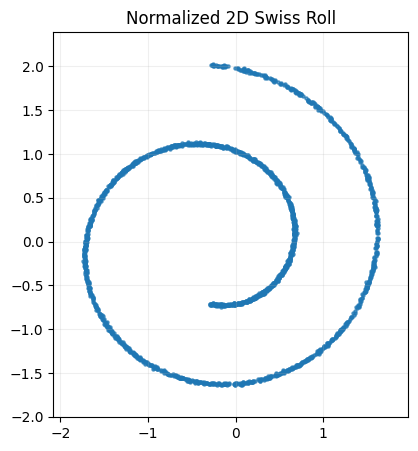

In [9]:
# Build dataset and loader
BATCH_SIZE = 256
dataset = SwissRoll2D(num_samples=10000, noise=0.05, normalize=True)
loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                    shuffle=True, drop_last=True)

# Peek at the dataset
with torch.no_grad():
    idx = torch.randperm(len(dataset))[:2000]
    plot_points(dataset.data[idx], title="Normalized 2D Swiss Roll")

### Exercise 1: A simple noise prediction network

Here we will implement a small neural network to approximate the noise added at each step. We will use a simple multi-layer perceptron (MLP) that takes as input the current time and the noisy data. The time allows the model to condition on the current stage of the diffusion process. Your task is to add activation functions + extra hidden layers before the final layer.

In [10]:
class MLP(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            # EX 1: Implement here two activation layers and a linear layer in between
            # 🎯🎯🎯 TODO: ... 🎯🎯🎯
            nn.ReLU(),                 # activation 1
            nn.Linear(hidden, hidden), # linear layer between activations
            nn.ReLU(),                 # activation 2
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t_norm):
        h = torch.cat([x, t_norm], dim=1)
        return self.net(h)


# Tiny helper: normalize integer time t to [0, 1]
def t_to_norm(t: torch.Tensor, T: int) -> torch.Tensor:
    if t.dim() == 0:
        t = t.view(1)
    return (t.float() / max(T - 1, 1)).unsqueeze(1)  # (B, 1)

## Part A: SimpleDiffusion
**Idea:**  
We create a simple denoising process where the model learns how to reverse one small step of noise at a time.

**Forward (noising):**  
- Starting from a clean point $x_0$, we repeatedly mix it with random noise, following the formulation:
  $$
    x_{t+1} = (1-\beta)x_t + \beta\,\epsilon,\quad \epsilon \sim N(0, I)
  $$
- Each step adds a little more noise; after many steps, the data becomes composed of entirely random samples.
- $\beta$ is the rate at which noise is added, called a noise schedule. It can be linear, static or evolve over time according to some policy.

**Training (residual prediction):**  
- Given a noised sample $x_t$ and time $t$, the model tries to predict how to recover $x_{t-1}$ from $x_t$.
- It learns a small residual $r(x_t, t)$, representing the noise that was added to get from $t-1$ to $t$ so that:
  $$
    x_{t-1} \approx x_t - r(x_t, t)
  $$
- We use mean squared error to train the network to make this correction as accurate as possible.

**Reverse (sampling):**  
- Starting from random noise, the model applies its learned correction step by step, slowly reconstructing new samples that look like the original data.

### Exercise 2: Forward diffusion step

Your task is to fill in the missing code in the `step_forward` method, following the equations provided above. Feel free to also take some time to read the rest of the code, to understand how our full diffusion model is built.

In [11]:
class SimpleDiffusion(nn.Module):
    """
    Very simple iterative denoiser:
      - Forward: x_{t+1} = (1 - beta) * x_t + beta * N(0, I)
      - Train: learn residual r(xt, t) to predict x_{t-1} from x_t
      - Sample: start from noise and apply x = x - r(x, t)
    """

    def __init__(self, T=10, beta=0.12, hidden=64, device=None):
        super().__init__()
        self.T = int(T) # The number of time steps we want the diffusion process to stretch over
        self.beta = float(beta) # The diffusion rate (how quickly we add noise)
        self.device = device if device is not None else torch.device("cpu") # GPU acceleration things
        self.net = MLP(hidden=hidden) # The model to predict the noise added at each step

    def forward(self, x_t, t):
        # The forward method for training (tricky naming as this is doing forward on the network, not forward diffusion) -> will predict per-step noise
        if t.dim() == 0:
            t = t.expand(x_t.shape[0])
        t_norm = t_to_norm(t, self.T)
        return self.net(x_t, t_norm)  # residual (B, 2)

    @torch.no_grad()
    def step_forward(self, x):
        # This is the forward process equation for the diffusion model (see equations above)
        noise = torch.randn_like(x)
        # EX 2: Write the noise mixing line
        # Forward: x_{t+1} = (1 - beta) * x_t + beta * N(0, I)
        # 🎯🎯🎯 TODO: x_next = ? 🎯🎯🎯
        x_next = ...
        return x_next

    @torch.no_grad()
    def q_sample(self, x0, t, eps=None):
        # Iterate 't' forward steps. Assumes uniform t across the batch.
        steps = int(t[0].item()) if t.dim() > 0 else int(t.item())
        x = x0.clone()
        for _ in range(steps):
            x = self.step_forward(x)
        return x

    @torch.no_grad()
    def sample(self, n, step_size=1.0, eta=0.0, collect_ts=None):
        # step_size and eta are unused; kept for compatibility with plotting helpers.
        x = torch.randn(n, 2, device=self.device)
        snaps = {}

        for t_int in reversed(range(self.T)):
            # Iterate all the way back from the last time step (fully noised sample) back to start
            t_vec = torch.full(
                (n,), t_int, device=self.device, dtype=torch.long)
            # Forward (PREDICT) the network to get the noise
            resid = self.forward(x, t_vec)
            # Subtract the resdiual
            x = x - resid
            if collect_ts is not None and t_int in collect_ts:
                snaps[t_int] = x.detach().clone()

        snaps[0] = x.detach().clone()
        return x, snaps

## Visualize forward noising for the toy model

This cell shows how repeated noising turns the spiral into a blob. It simply calls the step-forward method through `q_sample`.

In [12]:
toy_T = 10
toy_model = SimpleDiffusion(
    T=toy_T, beta=0.12, hidden=64, device=device).to(device)

with torch.no_grad():
    plot_forward_grid(
        toy_model,
        dataset.data,
        steps=[1, 3, 5, 7, 9],
        cols=3,
        title="SimpleDiffusion (toy) forward noising",
    )

AttributeError: 'ellipsis' object has no attribute 'cpu'

### Train the toy model

The next step is now to train the model we have just created. To do so, we need to:

- Build the noised trajectory $x_0, \ldots, x_T$ once per batch.
- Train the network to predict $x_{t-1}$ from $x_t$ by learning a residual $r(x_t, t-1)$.
- We loop over $t$ for clarity; $T$ is small so it runs fast. We will see a closed form to forward an entire $t$ steps in one go later.
- **Instructor note**: You can skim the loop and focus on implementing and understanding the residual and loss function.

### Exercise 3: Train the model

You will complete the training loop by implementing:
- The prediction of the next denoising step by subtracting the residual
- The loss calculation using an MSE loss function

In [ ]:
# Initialize variable parameters and optimizer
TOY_EPOCHS = 200
optimizer = torch.optim.Adam(toy_model.parameters(), lr=1e-3)
toy_losses = []

toy_model.train()
for epoch in range(1, TOY_EPOCHS + 1):
    running, batches = 0.0, 0

    for x0 in loader:
        x0 = x0.to(device)
        bsz = x0.size(0)

        # Build forward trajectory once: x_0, x_1, ..., x_T
        xts = [x0]
        for _ in range(toy_model.T):
            xts.append(toy_model.step_forward(xts[-1]))

        total_loss = 0.0
        for t in reversed(range(1, toy_model.T + 1)):
            xt = xts[t]
            x_prev = xts[t - 1]

            t_vec = torch.full((bsz,), t - 1, device=device, dtype=torch.long)
            resid = toy_model(xt, t_vec)
            # EX 3: Predict residual
            # We learn a residual r(x_t, t) so that x_{t-1} ~ x_t - r(x_t, t)
            # 🎯🎯🎯 TODO: x_prev_pred = ? 🎯🎯🎯
            x_prev_pred = ...
            # We compare our prediction to the true x_{t-1}
            # 🎯🎯🎯 TODO: loss = F.mse_loss() 🎯🎯🎯  # fill args
            loss = ...
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        running += total_loss / toy_model.T
        batches += 1

    avg = running / max(batches, 1)
    toy_losses.append(avg)
    if epoch % 25 == 0 or epoch == 1:
        print(f"[Toy] Epoch {epoch:3d}/{TOY_EPOCHS} | loss: {avg:.5f}")

### Reverse visualization and samples for the toy model

We will now watch the denoising unfold and compare generated samples to the dataset. Run the cell below.

In [ ]:
toy_model.eval()

plot_reverse_grid(
    toy_model,
    steps=[1, 2, 3, 5, 7],
    ref_points=dataset.data,
    n_show=3000,
    cols=3,
    title="SimpleDiffusion (toy) reverse",
)

We notice that the results are not perfect, but it is important to note that we use a rather simple MLP as the noise prediction network, which has limited expressive power. We also do not train it for very long. In practice, for more complex data such as images, much more powerful architectures are used in the noise prediction networks, like UNets, which we have covered earlier today. They can capture much richer structure, leading to better sample quality.

## Part B: DDPM ( Denoising Diffusion Probabilistic Model )

What we have seen so far is a very simple approach to a diffusion model, how it would be implemented if we were the follow the very first papers on the topic. In the meantime, more advanced and accurate techniques have been developed. DDPM, for example, is more complex and closer to real diffusion models used in practice. We will analyse it in more detailed in this part.

**Idea**:
- We corrupt the data with Gaussian noise that evolves according to the noise schedule $\beta$. However, we do the noising in one single step to avoid unnecessary iterations. Moreover, we adapt the sampling step by adding random noise after removing the predicted noise. We will later see why. Finally, we change the way we train to not use the entire trajectory, but a random time step instead.

**Forward (noising)**:
- We create noisy points with the same equation as earlier. However, a key insight proposed in DDPM is that we can reformulate our noise to do it in one shot. Given a noise schedule $\{\beta_t\}_{t=1}^T$ with $\beta_t\in(0,1)$, we define $\alpha_t=1-\beta_t$. Then noise with
  $$
    \mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\boldsymbol{\epsilon} \ \ \ \text{with} \ \ \ \boldsymbol{\epsilon}\sim N(0,\mathbf{I}) \ \ \ \text{and} \ \ \ \bar{\alpha}_t = \prod_{s=1}^t \alpha_s
  $$
- The noise schedule $\beta_t$ can evolve over time, for example in linear fashion, to make later samples noisier at a greater rate

**Training (noise predictions)**:
- Input: a noisy sample $x_t$ and its time $t$.
- Target: the exact noise $\epsilon$ used to make $x_t$.
- Loss: mean squared error between predicted and true noise.
- Why predict $\epsilon$: it keeps targets well-scaled across timesteps and stabilizes learning compared to predicting $x_0$ directly.
- Now standard framework for diffusion models.
- Note: Instead of making the noisy trajectory in full and denoising at every $t$ as in the standard approach above, we now just train with a random timestamp. This aporoach has been shown to lead to better generalization and more computational efficiency

**Reverese (sampling/denoising)**:
- Start from pure noise and iterate from $t=T-1$ down to 0.
- At each step, predict noise $\boldsymbol{\epsilon}_\theta(x_t, t)$ and move a bit toward denoised samples:
  $$x_{t-1}^*=\frac{1}{\sqrt{\alpha_t}}\Big(\mathbf{x}_t-\frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\Big)$$
- Add optional randomness:
  $$x_{t-1} = x_{t-1}^* + \sigma_t\mathbf{z} \ \ \ \text{where} \ \ \ \mathbf{z}\sim N(\mathbf{0}, \mathbf{I})$$
  - the noise schedule controls how aggressively we denoise each step.
  - $\sigma_t$ controls sample diversity (0 = deterministic, larger values = more variety).
  - not adding random noise risks collapsing all denoised samples to the same values, especially in high-dimensional space

If you are interested in the specifics for the math, training objectives, etc. consider checking out the DDPM paper linked at the start of this notebook.

<!-- OLD CONTENT "DDPM" BUT NOT REALLY -->

<!-- **Idea**:
- We corrupt data with Gaussian noise whose strength grows over time. If we can learn to predict that noise from a noisy sample and its time index, we can subtract it step by step to recover data, similarly to the prior model.

**Forward (noising)**:
- We create noisy points following
  $x_t = x_0 + \sigma(t)\,\epsilon$, with $\epsilon \sim \mathcal{N}(0, I)$.
- The schedule $\sigma(t)$ increases from 0 to $\sigma_{\max}$, so later steps are noisier.

**Training (noise prediction)**:
- Input: a noisy sample $x_t$ and its time $t$.
- Target: the exact noise $\epsilon$ used to make $x_t$.
- Loss: mean squared error between predicted and true noise.
- Why predict $\epsilon$: it keeps targets well-scaled across timesteps and stabilizes learning compared to predicting $x_0$ directly.

**Reverse (sampling / denoising)**:
- Start from pure noise and iterate from $t=T-1$ down to 0.
- At each step, predict noise $\hat{\epsilon}(x_t, t)$ and move a bit toward denoised samples:
  $$\text{mean\_step} = x_t - \text{step\_size}\cdot\sigma(t)\cdot\hat{\epsilon}$$
- Add optional randomness:
  $x_{t-1} = \text{mean\_step} + \text{eta}\cdot\sigma(t)\cdot z$, with $z \sim \mathcal{N}(0, I)$.
  - step_size controls how aggressively we denoise each step.
  - eta controls sample diversity (0 = deterministic, larger values = more variety). -->

### Exercise 4: Denoising in DDPM

You will implement the denoising step following the DDPM formulation above inside the `sample` function.

In [ ]:
class DDPM(nn.Module):
    """
    Minimal diffusion-like model for 2D points that predicts epsilon.
      - Forward: x_t = sqrt(alpha_bar_t)x_0 + sqrt(1-alpha_bar_t)eps
      - Train: predict eps from (x_t, t) via MSE
      - Sample: iterative denoising
    """

    def __init__(self, beta_schedule, T=100, hidden=128, device=None):
        super().__init__()
        self.T = int(T)
        self.beta = beta_schedule
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
        self.device = device if device is not None else torch.device("cpu")
        self.net = MLP(hidden=hidden)

    def forward(self, x_t, t):
        if t.dim() == 0:
            t = t.expand(x_t.shape[0])
        t_norm = t_to_norm(t, self.T)
        return self.net(x_t, t_norm)  # predicted eps (B, 2)

    @torch.no_grad()
    def q_sample(self, x0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(x0)
        alpha_bar_t = self.alpha_bar[t].unsqueeze(1).to(x0.device)
        return torch.sqrt(alpha_bar_t)*x0 + torch.sqrt(1-alpha_bar_t)*eps

    @torch.no_grad()
    def sample(self, n, step_size=0.5, eta=0.8, collect_ts=None):
        # Ignore step size and the eta (kept for compatibility with the plotting code)
        x = torch.randn(n, 2, device=self.device)
        snaps = {}

        for t in reversed(range(self.T)):
            t_vec = torch.full((n,), t, device=self.device, dtype=torch.long)
            beta_t = self.beta[t]
            alpha_t = self.alpha[t]
            alpha_bar_t = self.alpha_bar[t]

            noise_pred = self.forward(x, t_vec)

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            # EX 4: Complete the denoising step following equation above (use the added randomness!)
            # We will use sigma_t = sqrt(beta_t)
            # For all square roots you can just call torch.sqrt()
            # 🎯🎯🎯 TODO at t-1, x = ? 🎯🎯🎯
            x = ...

            if collect_ts is not None and t in collect_ts:
                snaps[t] = x.detach().clone()

        snaps[0] = x.detach().clone()
        return x, snaps

### Visualize forward noising for DDPM

- As $t$ increases, points spread out. We use a linear schedule for $\beta_t$ increasing in homogeneous steps from less aggressive $1e-4$ to more aggressive noising $0.02$.
- Note that these are hyperparameters and can be changed.
- Note also that a linear schedule is one of the simplest approaches we can take. More complex schedules might be better fit for different applications.

### Exercise 5: A simple noise schedule

- You will implement the linear schedule using the documentation for [torch.linspace](https://docs.pytorch.org/docs/stable/generated/torch.linspace.html).

In [ ]:
# DDPM IMPLEMENTATION NEW
T_ddpm = 100
BETA_START = 1e-4
BETA_END = 0.02

# EX 5: Create a linear noising schedule. Make sure to send it to the device in use (add .to(device) at the end)
# 🎯🎯🎯 TODO: beta_schedule = ?.to(device) 🎯🎯🎯
beta_schedule = ....to(device)
model = DDPM(beta_schedule=beta_schedule, T=T_ddpm, hidden=128, device=device).to(device)
print("DDPM params:", sum(p.numel()
      for p in model.parameters() if p.requires_grad))

with torch.no_grad():
    plot_forward_grid(
        model,
        dataset.data,
        steps=[10, 30, 50, 60, 90],
        cols=3,
        title="DDPM forward noising",
    )

### Train DDPM to predict $\epsilon$

- Sample a random $t$ per example.
- Create $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\boldsymbol{\epsilon}$.
- Predict $\epsilon$ and minimize MSE.

### Exercise 6: Generate noise, timesteps and the prediction

You will complete the training loop for DDPM by implementing:
- The timestep and random noise creation (consult documentation for [torch.randn_like](https://docs.pytorch.org/docs/stable/generated/torch.randn_like.html), [torch.randint](https://docs.pytorch.org/docs/stable/generated/torch.randint.html))
- The forward trajectory using this time step and noise by using `q_sample`

In [ ]:
EPOCHS = 800  # reduce if on CPU
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loss = []

model.train()
for epoch in range(1, EPOCHS + 1):
    running, batches = 0.0, 0

    for x0 in loader:
        x0 = x0.to(device)
        bsz = x0.size(0) # batch size

        # EX 6a: Calculate the noise (eps; random noise for the entire sample x0) and the timestep t (random integer constant for each element in the batch; use batch size)
        # 🎯🎯🎯 TODO: eps = ? 🎯🎯🎯
        # 🎯🎯🎯 TODO: t = ?.long().to(device) 🎯🎯🎯
        t = ....long().to(device)
        eps = ...
        # EX 6b: Create a noised sample by running the forward trajectory of q_sample of the model
        # 🎯🎯🎯 TODO: x_t = ? 🎯🎯🎯
        x_t = ...

        eps_pred = model(x_t, t)
        loss = F.mse_loss(eps_pred, eps)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item()
        batches += 1

    avg = running / max(batches, 1)
    train_loss.append(avg)
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | loss: {avg:.5f}")

# Plot the training curve
plt.figure(figsize=(6, 4))
plt.plot(train_loss)
plt.title("DDPM train loss (predict epsilon)")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.show()

### Reverse visualization and samples for DDPM

- Start from noise and denoise step by step.
- The noise schedule controls how heavily we denoise, and also the randomness in the reverse process.

In [ ]:
model.eval()

# Show snapshots at a few time steps during reverse denoising
plot_reverse_grid(
    model,
    steps=[10, 20, 40, 60, 90 ],
    ref_points=dataset.data,
    n_show=3000,
    cols=3,
    title="Reverse",
)

**Instructor note:** Just run this cell, you can ignore the code details.

In [ ]:
#@title <Final visualization of original sample vs denoised sample> {display-mode: "form"}

# Draw new samples from the model
with torch.no_grad():
    samples, _ = model.sample(n=5000, step_size=0.9, eta=0.8, collect_ts=None)
    samples = samples.cpu()

# Compare data vs generated samples
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(dataset.data[:3000, 0], dataset.data[:3000, 1], s=5, alpha=0.7)
plt.title("Data")
ax = plt.gca()
ax.set_aspect("equal", "box")
plt.grid(alpha=0.2)

plt.subplot(1, 2, 2)
plt.scatter(samples[:3000, 0], samples[:3000, 1],
            s=5, alpha=0.7, color="tab:orange")
plt.title("Samples (simple iterative denoiser)")
ax = plt.gca()
ax.set_aspect("equal", "box")
plt.grid(alpha=0.2)
plt.show()

## FAQ and tips

- Why predict noise instead of clean data?
  - Predicting $\epsilon$ makes the problem well-scaled and avoids difficulties from predicting $x_0$ directly.
- What is $\beta_t$?
  - It is the strength of the noise at time $t$, our noising schedule.
  - It can be anything, from the simple linear schedule we used here, to more complex schedules.
- What is $\sigma_t$ in the reverse process?
  - It is the strength of the random component in denoising at time $t$. We simply use the noise schedule itself for this, but you can use other methods.
- What happens if I change $T$
  - Higher $T$ gives more, smaller steps. This can help stability but costs more compute.
- What happens if I change the noise schedule or $\sigma_t$ in sampling
  - Larger noise schedule ranges noise and denoise faster but can overshoot in denoising.
  - Larger $\sigma_t$ adds randomness and can increase sample diversity.


# Mega Bonus: Image Generation and Latent Diffusion Models

We have so far talked about diffusion models in their capacity as general probabilistic models (following the approach of Dickenstein in the original diffusion paper, and later the more advanced method of Denoising Diffusion Probabilistic Models (DDPMs)). It turns out diffusion models are also powerful tools for image generation, which was the real purpose of the DDPM paper. How do we get from the probabilistic formulation to images? In a simplified manner, think of each pixel in the image as a random variable. Each of these random variables receives a state, from all possible states of pixels (i.e. all their possible colors). That makes our image simply a high-dimensional concatenation of random variables, or a complex multivariate distribution. We can use diffusion models to generate new samples from this distribution.

While the simple models shown previously have interesting results, they also have several limitations: model capacity is low, noise scheduling is very simple, and we cannot generate conditionally (i.e. items of a specific class). Simple diffusion models as previously seen can also quickly become computationally expensive, require large amounts of memory, and can be slow to train and sample from, especially when working directly in high-dimensional pixel space with large images.

Latent Diffusion Models (LDMs) address these challenges by performing the diffusion process in a compressed, lower-dimensional latent space rather than directly on images. This is achieved by first encoding images into a latent, lower-dimensional, representation using a Variational Autoencoder (VAE) - which you will see in module 4 of this course. By operating in this latent space, LDMs can significantly reduce computational costs, enable larger and more expressive models, and accelerate both training and sampling.

In this notebook, we will:
- Introduce the concept of latent spaces and how VAEs are used to encode and decode images. Do not worry too much about this part, it will be covered in-depth in module 4.
- Explore how diffusion models can be applied in latent space, rather than pixel space.
- Implement conditional diffusion, allowing us to guide the generation process with additional information (such as class labels or text).
- Improve the denoising network to have more expressive power.
- Improve the noise schedule to enhance sample quality and training stability.
- Increase model capacity, taking advantage of the efficiency gains from working in latent space.

By the end of this notebook, you will understand the key ideas behind Latent Diffusion Models and how they overcome the limitations of previous diffusion-based approaches.

Additional reads:
- Dataset used: [MedMNIST](https://ieeexplore.ieee.org/document/9434062/), available for download or as a library via [MedMNIST web](https://medmnist.com/).
- Variational Autoencoders: [In its original paper on arXiv](https://arxiv.org/abs/1312.6114).

## The Dataset

We will use the MedMNIST dataset, a collection of standardized biomedical image datasets designed for machine learning research and education. It is similar in spirit to the classic MNIST dataset, but instead of handwritten digits, it contains small medical images from a variety of modalities, such as X-rays, pathology slides, and more.

- Use of diffusion models in medicine particularly promising
- Medical data often scarce, expensive or dangerous to collect, has privacy concerns and need for expert annotation.
- Generative models can synthesize and augment data, and help validate algorithms
- MedMNIST is ideal stepping stone between toy datasets and real research, provides computational manageability while retaining importatnt biomedical features.
- We use the BloodMNIST subset, consisting of blood cell images.

In [ ]:
!pip install medmnist

**Instructor's note:** Run this cell, it just imports the necessary components and instantiates our dataset.

In [ ]:
#@title <Imports and dataset setup> {display-mode: "form"}

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import math
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from medmnist import BloodMNIST
from PIL import Image
from IPython.display import display
from tqdm.auto import tqdm

# Dataset creation, in this case with a larger base size for images (224x224)
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = BloodMNIST(split="train", download=True, size=224, transform=data_transform)
print(train_dataset)

- Each dataset is a PyTorch-compatible class, extending Dataset (can easily wrap with `DataLoader`)
- Each dataset provides images along with corresponding labels

**Instructor's note:** Run the following few cells that will help you visualize the dataset.

In [ ]:
# Visualize a montage of images from the training dataset
train_dataset.montage(length=3)

In [ ]:
# Visualize the first image and its label from the training dataset
# Print the shape of the tensors
x, y = train_dataset[0]
y_tensor = torch.from_numpy(y)
print(x.shape)
print(y_tensor.shape)

In [ ]:
display(TF.to_pil_image(x))

In [ ]:
print(y)

## The variational autoencoder (VAE)

Before understanding Latent Diffusion Models, we need one key idea: **latent spaces**, and how we can use them to drastically reduce training and generation costs. A **latent space** is a lower-dimensional representation of data that captures its most important features. The idea is to map high-dimensional data (like images) into a compressed form, where similar data points are close together. This makes it easier to analyze, generate, or manipulate data.

---

**Autoencoders (AEs)** are neural networks designed to learn such representations. They consist of two parts:
- **Encoder**: Maps the input data $\mathbf{x}$ to a latent vector $\mathbf{z}$.
- **Decoder**: Reconstructs the input $\mathbf{x}$ from the latent vector $\mathbf{z}$.

While they can learn useful representations, they have several limitations:
- The latent space is often **unstructured** and may not be continuous or smooth, making it difficult to sample new data.
- There is no guarantee that points sampled from the latent space will decode to realistic data.
- They do not provide a probabilistic interpretation of the latent space.

**Variational Autoencoders (VAEs)** address these issues by introducing a probabilistic framework. Instead of encoding each input as a single point in latent space, VAEs encode it as a **distribution** (typically Gaussian). This encourages the latent space to be continuous and allows for meaningful sampling. A VAE is thus a model that:

- Compresses an image into a smaller latent representation  
- Ensures that this latent space is smooth and structured  
- Allows us to sample new data from it

Why does this matter?

In Latent Diffusion Models, we **do not** run diffusion directly on pixels. Instead, we:

1. Compress images using a VAE  
2. Run diffusion in the smaller latent space  
3. Convert back to pixel space when generating

This makes training and generation much more efficient.

---

**Instructor’s Note**

The VAE implementation is included below for completeness and for usage with the latent diffusion model, but you can safely skip reading the code for now. It is fully contained in the `vae_diffusion.py` file. VAEs will be covered in detail in Module 4 and you will program one yourself. For now, just run the cell(s) below.

<details>
<summary>Mathematical details of the VAE (will be covered in module 4!!)</summary>
The autoencoder is trained to minimize the reconstruction error:
$$
\mathcal{L}_{\text{AE}} = \|\mathbf{x} - \hat{\mathbf{x}}\|^2
$$
where $\hat{\mathbf{x}}$ is the reconstruction of $\mathbf{x}$. The encoder and decoder are parameterized with neural networks.

**Variational Autoencoders (VAEs)** address these issues of traditional autoencoders by introducing a probabilistic framework. Instead of encoding each input as a single point in latent space, VAEs encode it as a **distribution** (typically Gaussian). This encourages the latent space to be continuous and allows for meaningful sampling.

### How VAEs Work

1. **Encoder**: Maps input $\mathbf{x}$ to parameters of a distribution over latent variables, usually the mean $\boldsymbol{\mu}(\mathbf{x})$ and standard deviation $\boldsymbol{\sigma}(\mathbf{x})$ of a Gaussian:
   $$
   q_\phi(\mathbf{z}|\mathbf{x}) = N(\mathbf{z}; \boldsymbol{\mu}(\mathbf{x}), \text{diag}(\boldsymbol{\sigma}^2(\mathbf{x})))
   $$
2. **Sampling**: A latent vector $\mathbf{z}$ is sampled from this distribution using the "reparameterization trick":
   $$
   \mathbf{z} = \boldsymbol{\mu}(\mathbf{x}) + \boldsymbol{\sigma}(\mathbf{x}) \odot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim N(0, I)
   $$
3. **Decoder**: Maps $\mathbf{z}$ back to a reconstruction $\hat{\mathbf{x}}$ sampling from the distribution $p_\theta(\mathbf{x}|\mathbf{z})$.

### VAE Loss Function

The VAE is trained to maximize the **evidence lower bound (ELBO)**:
$$
\mathcal{L}_{\text{VAE}} = \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}[\log p_\theta(\mathbf{x}|\mathbf{z})] - D_{\text{KL}}(q_\phi(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}))
$$
- The first term is the expected reconstruction log-likelihood.
- The second term is the Kullback-Leibler (KL) divergence between the approximate posterior and the prior (usually $p(\mathbf{z}) = N(0, I)$).

### Advantages of VAEs

- The latent space is **continuous** and **structured**, making it possible to interpolate and sample new data.
- The probabilistic formulation allows for **generative modeling**: we can sample $\mathbf{z} \sim p(\mathbf{z})$ and decode to generate new data.
- The KL divergence regularizes the latent space, preventing overfitting and encouraging disentanglement.
</details>

### Core Idea

Autoencoder → compress  
VAE → compress + structure  
Latent Diffusion → generate in that structured latent space

In [ ]:
#@title <Imports for the VAE> {display-mode: "form"}
!wget https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/refs/heads/week2/Diffusion%20CX/vae_diffusion.py

from vae_diffusion import StableStyleVAE, train_vae

**IF YOU ARE INTERESTED IN THE DETAILS OF THE IMPLEMENTATION**

<details>
<summary>Explanation of Code defining the VAE</summary>
The provided code implements a Variational Autoencoder (VAE) tailored for 3×224×224 images, such as those from the BloodMNIST dataset. The VAE consists of three main components: the encoder, the decoder, and the training loop.

**Encoder:**  
The encoder uses a series of convolutional layers to progressively reduce the spatial dimensions of the input image while increasing the number of feature channels. After flattening the final feature map, two fully connected layers output the mean ($\mu$) and log-variance ($\log \sigma^2$) vectors, which parameterize a Gaussian distribution in the latent space. This allows the model to represent each input as a distribution rather than a single point.

**Decoder:**  
The decoder maps the latent vector back to the image space. It first uses a fully connected layer to reshape the latent vector into a feature map, then applies a series of transposed convolutional layers (also known as deconvolutions) to upsample back to the original image size. The final layer uses a sigmoid activation to ensure output pixel values are in the $[0, 1]$ range.

**Loss Function:**  
The VAE loss combines two terms:
- **Reconstruction Loss:** Measures how well the output image matches the input. Here, mean squared error (MSE) is used.
- **KL Divergence:** Regularizes the latent space by encouraging the learned distribution to be close to a standard normal distribution.

**Training Loop:**  
The training loop iterates over the dataset in batches, passing each batch through the VAE, computing the loss, and updating the model parameters using the Adam optimizer. The model is trained for a specified number of epochs, and the average loss per epoch is printed for monitoring.

This architecture enables the VAE to learn a meaningful, continuous latent space for high-dimensional images, making it suitable for downstream generative tasks and as a foundation for
</details>

**Instructor's note:** You can also safely skip reading through the training loop and just run it. It will save the model weights in `vae.pth` such that the model can be loaded anew when training our latent diffusion model later. If you want to have a look at the loop it is located in `vae_diffusion.py`.

<details>
<summary>Explanation of the training loop</summary>

## Training the Encoder

We now proceed with the training loop for our VAE. The training is performed over 50 epochs with a batch size of 64, using the Adam optimizer.

At each epoch:
- The model is set to training mode.
- For each batch, images are moved to the appropriate device.
- The VAE processes the images, producing reconstructions (`x_recon`), means (`mu`), and log-variances (`logvar`) for the latent variables.
- The loss is computed using a custom `vae_loss` function, which typically combines reconstruction loss and KL divergence.
- Gradients are computed and the optimizer updates the model parameters.

After the final epoch, the trained model's weights are saved to disk such that we can load the VAE later down the line.

</details>

In [ ]:
BATCH_SIZE = 16 # The batch size for training
EPOCHS = 20 # The training epochs
in_channels = 3 # The channels of the input image (3 = RGB)
latent_dim = 4 # The dimensions of the latent space

train_vae(in_channels=in_channels, latent_dim=latent_dim, train_dataset=train_dataset, n_epochs=EPOCHS, batch_size=BATCH_SIZE)

## Visualizing the reconstruction

**Instructor's note:** You may also skip the understanding of this cell, it is just for plotting. In essence, we plot the full images, then pass them through our VAE, and then get the output reconstruction from the decoder, which we also plot. Run the cell to visualize it.

In [ ]:
#@title <Visualization of VAE reconstruction> {display-mode: "form"}

# For visualization put the device on the cpu
device="cpu"
dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
vae = StableStyleVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load("vae.pth", map_location=device))
vae.eval()

with torch.no_grad():
    imgs = next(iter(dataloader))[0].to(device)  # assumes (img, label) tuple
    recons, _, _ = vae(imgs)
    imgs = imgs.cpu()
    recons = recons.cpu()

# Show a few original and reconstructed images side by side
n = 4  # number of images to display
plt.figure(figsize=(2 * n, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(imgs[i].permute(1, 2, 0).clamp(0, 1))
    plt.axis('off')
    if i == 0:
        plt.title("Original")
    # Reconstruction
    plt.subplot(2, n, n + i + 1)
    plt.imshow(recons[i].permute(1, 2, 0).clamp(0, 1))
    plt.axis('off')
    if i == 0:
        plt.title("Reconstruction")
plt.show()

## The noise prediction network

You've seen UNet's during this second module and had coding exercises on them, so we will not re-invent the wheel and instead use existing model structures from the `diffusers` library. We will, however, make sure to implement class conditioning in the UNet so that it can generated images from one specific blood cell type. This is achieved by embedding the class label into a vector using an embedding layer, and then concatenating this vector (after reshaping and expanding it to match the image dimensions) with the input image along the channel dimension. The modified input is then passed through the UNet, which now has additional input channels to accommodate the class information.

This allows the diffusion model to learn how to generate images that correspond to a given class, rather than generating images unconditionally. The forward method now takes class labels as an additional argument, embeds them, and ensures the class information is available at every spatial location in the input. This technique is a simple but powerful way to guide the generative process using label information.

### Exercise 7: A denoising UNet

Please complete the below code cell implementing:
- The embedding for the class conditioning (use the documentation for [nn.Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html))
- The net input and forward method (use the documentation for [torch.cat](https://docs.pytorch.org/docs/stable/generated/torch.cat.html), and, optionally, for [UNet2DModel](https://huggingface.co/docs/diffusers/en/api/models/unet2d) from diffusers)

In [ ]:
class ClassConditionedUnet(nn.Module):
    def __init__(self, num_classes=8, class_emb_size=4, latent_dim=4):
        super().__init__()

        # The embedding layer will map the class label to a vector of size class_emb_size
        # EX 7a: Create a class embedding for the number of class and their embedding size
        # 🎯🎯🎯 TODO: self.class_emb = ? 🎯🎯🎯
        self.class_emb = ...

        # Self.model is an unconditional UNet with extra input channels to accept the conditioning information (the class embedding)
        self.model = UNet2DModel(
            sample_size=28,  # the target image resolution
            in_channels=latent_dim + class_emb_size,  # Additional input channels for class cond.
            out_channels=latent_dim,  # the number of output channels
            layers_per_block=2,  # how many ResNet layers to use per UNet block
            block_out_channels=(32, 64, 64),
            norm_num_groups=8,
            down_block_types=(
                "DownBlock2D",  # a regular ResNet downsampling block
                "DownBlock2D",
                "DownBlock2D",
            ),
            up_block_types=(
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",  # a regular ResNet upsampling block
            ),
        )

    # Our forward method now takes the class labels as an additional argument
    def forward(self, x, t, class_labels):
        # Shape of x:
        bs, ch, w, h = x.shape

        # class conditioning in right shape to add as additional input channels
        class_cond = self.class_emb(class_labels)  # Map to embedding dimension
        class_cond = class_cond.view(bs, class_cond.shape[1], 1, 1).expand(bs, class_cond.shape[1], w, h)
        # x is shape (bs, ch, 28, 28) and class_cond is now (bs, ch + emb_size, 28, 28)

        # Net input is now x and class cond concatenated together along dimension 1 (channels)
        # EX 7b: Concatenate the input and the class along channels
        # 🎯🎯🎯 TODO: net_input = ? 🎯🎯🎯
        net_input = ...  # (bs, ch + emb_size, 28, 28)

        # Feed this to the UNet alongside the timestep and return the prediction
        # EX 7c: Feed the relevant input to the net
        # 🎯🎯🎯 TODO: return self.model(?).sample 🎯🎯🎯
        return self.model(...).sample  # (bs, ch, 28, 28)

## The diffusion model from earlier, for images

We now need to construct our diffusion model, similarly to what we did before, but to train for images. We use a more advanced noise schedule here, also from the diffusers library. Then, we load the VAE from the checkpoint we made earlier, and instantiate our dataloader with the new training parameters. We also need a MSE loss for the noise prediction and an optimizer. Finally, we keep track of the losses to plot the curve later.

**Instructor's note:** You may just run this cell for setting up the training.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
T_ddpm = 250 # Diffusion steps
BATCH_SIZE = 128 # The batch size for training
EPOCHS = 30 # The training epochs
in_channels = 3 # The channels of the input image (3 = RGB)
latent_dim = 4 # The dimensions of the latent space
lr = 1e-3

# Create a scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=T_ddpm, beta_schedule="squaredcos_cap_v2")

# Load the VAE's checkpoint, set it to eval (not training!)
vae = StableStyleVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)
vae.load_state_dict(torch.load("vae.pth", map_location=device))
vae.eval()

# Redefining the dataloader to set the batch size higher than the demo of 8
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Our network
num_classes=8
class_embed_size=4
net = ClassConditionedUnet(num_classes=num_classes, class_emb_size=class_embed_size, latent_dim=latent_dim).to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=lr)

# Keeping a record of the losses for later viewing
losses = []

## Training the Diffusion Model

We now train the model using the setup we've made.

### Exercise 8: The LDM training loop

You will complete the implementation of the training loop by implementing:
- The encoding of the samples into latent space with the VAE
- The noising of the latents via the noise scheduler (consult documentation for [torch.randn_like](https://docs.pytorch.org/docs/stable/generated/torch.randn_like.html), [torch.randint](https://docs.pytorch.org/docs/stable/generated/torch.randint.html), and [DDPMScheduler's add_noise method](https://huggingface.co/docs/diffusers/v0.36.0/api/schedulers/ddpm))
- Calling the noise prediction network to get the noise
- Calculate the loss between the prediction network and the true added noise

In [ ]:
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, (x, y) in enumerate(progress_bar):

        # Get some data and prepare the corrupted version
        x = x.to(device)
        y = y.to(device).squeeze(-1)

        with torch.no_grad():
            # EX 8a: Encode the sample into latent space with the VAE
            # 🎯🎯🎯 TODO: _, mu, logvar = ? 🎯🎯🎯
            _, mu, logvar = ...
            latents = mu * 0.18215  # Stable diffusion scale

        # EX 8b: Calculate the noise (random noise for the entire latent) and the timesteps (random integer constant for each element in the latent)
        # 🎯🎯🎯 TODO: noise = ? 🎯🎯🎯
        # 🎯🎯🎯 TODO: timesteps = ?.long().to(device) 🎯🎯🎯
        noise = ...
        timesteps = ....long().to(device)

        # EX 8c: Apply the noise to the latents using the scheduler
        # 🎯🎯🎯 TODO: noisy_latents = ? 🎯🎯🎯
        noisy_latents = ...

        # EX 8d: Get the model prediction
        # 🎯🎯🎯 TODO: pred = ? 🎯🎯🎯
        pred = ...  # Note that we pass in the labels y

        # EX 8e: Calculate the loss
        # 🎯🎯🎯 TODO: loss = ? 🎯🎯🎯
        loss = ...  # How close is the output to the noise

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        loss_val = loss.item()
        losses.append(loss_val)
        epoch_loss += loss_val

        progress_bar.set_postfix({"loss": f"{loss_val:.4f}"})

    avg_epoch_loss = epoch_loss / len(train_dataloader)
    print(f"\nEpoch {epoch+1} complete | Avg loss: {avg_epoch_loss:.4f}\n")

# View the loss curve
plt.plot(losses)
plt.title("Latent Diffusion Training Loss")
plt.show()

## Visualizing a sample

Finally, we visualize a sample by starting with pure noise in the shape of the latents, denoising iteratively each timestep with the predicted noise, and then decoding the latents to a full sized image with our VAE.

**Instructor's note:** You may just run this cell, editing the class_label at the bottom to check different types of blood cells.

In [ ]:
net.eval()
vae.eval()

@torch.no_grad()
def sample_from_class(class_label, num_inference_steps=T_ddpm):

    # Prepare class tensor
    class_labels = torch.tensor([class_label], device=device)

    # Start from pure noise in latent space
    latents = torch.randn((1, 4, 28, 28), device=device)

    # Set scheduler timesteps
    noise_scheduler.set_timesteps(num_inference_steps)
    noise_scheduler.timesteps = noise_scheduler.timesteps.to(device)

    for t in noise_scheduler.timesteps:
        # Predict noise
        noise_pred = net(latents, t.unsqueeze(0), class_labels)

        # Compute previous step
        latents = noise_scheduler.step(
            model_output=noise_pred,
            timestep=t,
            sample=latents
        ).prev_sample

    # Undo Stable Diffusion scaling
    latents = latents / 0.18215

    # Decode to image space
    image = vae.decoder(latents)

    # Map from [-1,1] to [0,1]
    image = (image.clamp(-1, 1) + 1) / 2

    return image

class_label = 6
image = sample_from_class(class_label=class_label)

plt.imshow(image[0].permute(1,2,0).cpu())
plt.axis("off")
plt.title(f"Generated Sample - Class {class_label}")
plt.show()